# 1. Library Importing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# 2. Dataset Loading

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 3. Visualize Sample Images

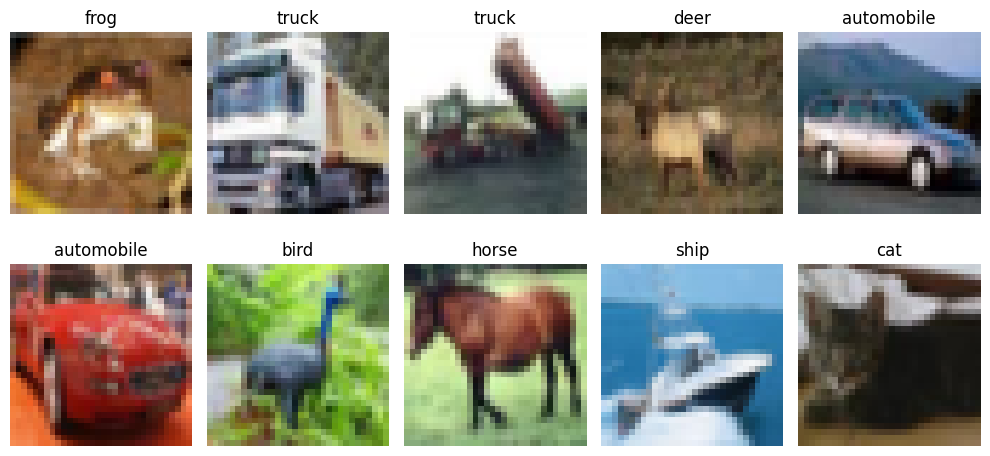

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 4. Preprocessing

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# **5. Models**

# 5.1 ANN Model

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2688 - loss: 1.9912 - val_accuracy: 0.3408 - val_loss: 1.8617
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.3118 - loss: 1.8810 - val_accuracy: 0.3454 - val_loss: 1.8183
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3320 - loss: 1.8256 - val_accuracy: 0.3730 - val_loss: 1.7547
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3476 - loss: 1.7914 - val_accuracy: 0.3802 - val_loss: 1.7398
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3583 - loss: 1.7659 - val_accuracy: 0.3758 - val_loss: 1.7389
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3691 - loss: 1.7378 - val_accuracy: 0.4148 - val_loss: 1.6710
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3743 - loss: 1.7183 - val_accuracy: 0.4136 - val_loss: 1.6628
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3790 - loss: 1.7043 - val_accuracy: 0.

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4213 - loss: 1.6378
ANN Test Accuracy: 0.4212999939918518


# 5.2 CNN Model

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.4563 - loss: 1.5160 - val_accuracy: 0.2688 - val_loss: 2.2321
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5918 - loss: 1.1575 - val_accuracy: 0.5740 - val_loss: 1.2044
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6585 - loss: 0.9755 - val_accuracy: 0.6622 - val_loss: 0.9444
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7003 - loss: 0.8597 - val_accuracy: 0.6718 - val_loss: 0.9608
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7365 - loss: 0.7574 - val_accuracy: 0.7140 - val_loss: 0.8260
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7631 - loss: 0.6727 - val_accuracy: 0.7122 - val_loss: 0.8560
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7849 - loss: 0.6061 - val_accuracy: 0.6804 - val_loss: 1.0112
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8035 - loss: 0.5505 - val_accuracy: 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7208 - loss: 0.9276
CNN Test Accuracy: 0.72079998254776


## Comparing Learning Curves

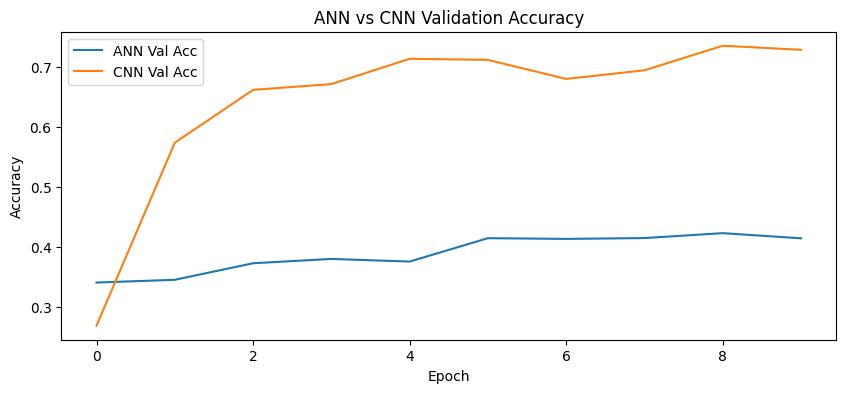

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 5.3 Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1, batch_size=64)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3615 - loss: 1.7485 - val_accuracy: 0.4852 - val_loss: 1.4144
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4614 - loss: 1.4943 - val_accuracy: 0.5354 - val_loss: 1.2897
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5011 - loss: 1.3974 - val_accuracy: 0.5600 - val_loss: 1.2092
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5230 - loss: 1.3380 - val_accuracy: 0.5702 - val_loss: 1.2004
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5395 - loss: 1.2963 - val_accuracy: 0.5532 - val_loss: 1.2252
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5504 - loss: 1.2611 - val_accuracy: 0.6070 - val_loss: 1.0879
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5650 - loss: 1.2383 - val_accuracy: 0.6152 - val_loss: 1.0924
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5750 - loss: 1.2052 - val_accuracy: 0

In [11]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Augmented CNN Test Loss: {aug_test_loss:.4f} Test Accuracy: {aug_test_acc:.4f} ({aug_test_acc*100:.2f}%)")

Augmented CNN Test Loss: 1.0966 Test Accuracy: 0.6212 (62.12%)


# Comparison Table

In [12]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4213
1,CNN,0.7208
2,Augmented CNN,0.6212




---



# Questions/ Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# Task 1: Increase ANN layers and observe performance

In [13]:
deep_ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

deep_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_ann_model.summary()

print("\nTraining Deep ANN (10 epochs)...")
deep_ann_history = deep_ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

deep_ann_test_loss, deep_ann_test_acc = deep_ann_model.evaluate(x_test_flat, y_test, verbose=0)

print(f"ANN Baseline Test Accuracy : {ann_test_acc:.2f} ({ann_test_acc*100:.2f}%)")
print(f"ANN Deep Test Accuracy : {deep_ann_test_acc:.2f} ({deep_ann_test_acc*100:.2f}%)")
print(f"Change : {(deep_ann_test_acc - ann_test_acc)*100:+.2f} percentage")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,746,506 (6.66 MB)

 Trainable params: 1,746,506 (6.66 MB)

 Non-trainable params: 0 (0.00 B)


Training Deep ANN (10 epochs)...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.2125 - loss: 2.0846 - val_accuracy: 0.2976 - val_loss: 1.9262
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2790 - loss: 1.9363 - val_accuracy: 0.3048 - val_loss: 1.8783
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3004 - loss: 1.8921 - val_accuracy: 0.3412 - val_loss: 1.8222
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3133 - loss: 1.8638 - val_accuracy: 0.3562 - val_loss: 1.8002
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3230 - loss: 1.8409 - val_accuracy: 0.3582 - val_loss: 1.8234
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3317 - loss: 1.8262 - val_accuracy: 0.3680 - val_loss: 1.7897
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3377 - loss: 1.8102 - val_accuracy: 0.3754 - val_loss: 1.7464
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.346

**Task 1 insights**: Marginal accuracy has been increased because ANN's real limitation is architectural and that is flattened input loses spatial information and there is no depth.
So it is unable to learn and not prediction well
- Also compare to previous less deeper ann this one worked even worst

# Task 2: Change CNN filters from 32→64→128

In [14]:
cnn_update_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(10, activation="softmax")
])

cnn_update_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_update_history = cnn_update_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

cnn_update_test_loss, cnn_update_test_acc = cnn_update_model.evaluate(x_test_norm, y_test, verbose=0)

print(f"CNN 32->64->128 Test Acc: {cnn_update_test_acc:.2f}  ({cnn_update_test_acc*100:.2f}%)")
print(f"CNN Baseline Test Accuracy: {cnn_test_acc:.2f} ({cnn_test_acc*100:.2f}%)")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.4568 - loss: 1.5433 - val_accuracy: 0.5598 - val_loss: 1.2819
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6118 - loss: 1.1153 - val_accuracy: 0.6162 - val_loss: 1.1319
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6732 - loss: 0.9386 - val_accuracy: 0.6508 - val_loss: 1.0485
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7223 - loss: 0.7994 - val_accuracy: 0.6464 - val_loss: 1.0397
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7570 - loss: 0.6901 - val_accuracy: 0.6802 - val_loss: 0.9439
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7903 - loss: 0.5977 - val_accuracy: 0.6812 - val_loss: 0.9733
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8152 - loss: 0.5221 - val_accuracy: 0.6790 - val_loss: 1.1488
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8353 - loss: 0.4634 - val_accuracy: 

**Task 2 insight**: This is the same model we have been asked to move the filter to 32 64 128 and i've been using this already as it was already given in the LMS file so no change

# Task 3: Increase epochs to 20

In [15]:
cnn_20Epoch_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_20Epoch_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_20Epoch_history = cnn_20Epoch_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

cnn_20Epoch_test_loss, cnn_20Epoch_test_acc = cnn_20Epoch_model.evaluate(x_test_norm, y_test, verbose=0)

print(f"CNN + 20Epoch Test Acc: {cnn_20Epoch_test_acc:.2f}  ({cnn_20Epoch_test_acc*100:.2f}%)")
print(f"CNN Baseline Test Accuracy: {cnn_test_acc:.2f} ({cnn_test_acc*100:.2f}%)")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.4361 - loss: 1.5692 - val_accuracy: 0.5716 - val_loss: 1.2452
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5999 - loss: 1.1361 - val_accuracy: 0.5706 - val_loss: 1.2988
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6680 - loss: 0.9456 - val_accuracy: 0.7040 - val_loss: 0.8548
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7208 - loss: 0.8051 - val_accuracy: 0.7012 - val_loss: 0.8801
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7566 - loss: 0.6963 - val_accuracy: 0.7096 - val_loss: 0.8947
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7859 - loss: 0.6055 - val_accuracy: 0.7166 - val_loss: 0.9369
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8134 - loss: 0.5326 - val_accuracy: 0.7046 - val_loss: 0.9600
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8309 - loss: 0.4766 - val_accuracy: 

**Task 3 insight**: Accuracy improveed but inconsistent val_loss also without early stopping this can cause overfitting

# Task 4: Add EarlyStopping

In [16]:
cnn_early_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_early_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

cnn_early_history = cnn_early_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

actual_epochs = len(cnn_early_history.history['val_accuracy'])
cnn_early_test_loss, cnn_early_test_acc = cnn_early_model.evaluate(x_test_norm, y_test, verbose=0)

print(f"Training stopped at epoch: {actual_epochs} / 20")
print(f"CNN + EarlyStopping Test Acc: {cnn_early_test_acc:.2f} ({cnn_early_test_acc*100:.2f}%)")
print(f"CNN Baseline Test Accuracy: {cnn_test_acc:.2f} ({cnn_test_acc*100:.2f}%)")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4573 - loss: 1.5440 - val_accuracy: 0.5576 - val_loss: 1.2723
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6083 - loss: 1.1219 - val_accuracy: 0.5786 - val_loss: 1.3642
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6830 - loss: 0.9162 - val_accuracy: 0.6718 - val_loss: 0.9491
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7240 - loss: 0.7888 - val_accuracy: 0.6174 - val_loss: 1.1044
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7656 - loss: 0.6724 - val_accuracy: 0.6642 - val_loss: 1.0214
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7967 - loss: 0.5777 - val_accuracy: 0.7298 - val_loss: 0.8273
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8204 - loss: 0.5112 - val_accuracy: 0.5130 - val_loss: 2.3228
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8434 - loss: 0.4443 - val_accuracy: 

**Task 4 insight** - Early stopping prevents overfitting and saves computational power and in this case it produced good result too by restroing best weights and getting best accuracy compare to previos Task models

# Task 5: Add data augmentation training

In [18]:
aug_full_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_full_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_aug = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

aug_full_history = aug_full_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_aug],
    verbose=1
)

aug_full_test_loss, aug_full_test_acc = aug_full_model.evaluate(x_test_norm, y_test, verbose=0)

print(f"CNN + AUG: +{(aug_full_test_acc - cnn_test_acc)*100:.2f} percentage points")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.3456 - loss: 1.8039 - val_accuracy: 0.4448 - val_loss: 1.5846
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.4624 - loss: 1.4875 - val_accuracy: 0.4838 - val_loss: 1.4846
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5150 - loss: 1.3557 - val_accuracy: 0.5784 - val_loss: 1.1780
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5550 - loss: 1.2610 - val_accuracy: 0.6116 - val_loss: 1.0905
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5869 - loss: 1.1707 - val_accuracy: 0.6352 - val_loss: 1.1283
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.6114 - loss: 1.1215 - val_accuracy: 0.6200 - val_loss: 1.1013
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6326 - loss: 1.0623 - val_accuracy: 0.6714 - val_loss: 0.9541
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6469 - loss: 1.0207 - val_a

In [23]:
print(f"CNN + 20 Epochs + EarlyStopping: {aug_full_test_acc*100:.2f}%")

CNN + 20 Epochs + EarlyStopping: 74.10%


Task 5 has produced **Best overall accuracy**

# **Conclusion**
- **ANN works**, but it achieves only ~49–52% test accuracy and ignores image structure
- **CNN extracts spatial features**, so it performs significantly better ~68–72% accuracy
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**


 - Full Augmented CNN + EarlyStopping (Task 5) — best generalisation
 - CNN + 20 Epochs + EarlyStopping (Task 4) — optimal training length